In [101]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [102]:
import os
import pandas as pd

In [103]:
import src.global_config as global_cfg
import src.stats.config as cfg
import src.stats.data_loader as loader
import src.stats.analysis as analysis
import src.stats.visualization as viz
import src.stats.category_plots as cat_plots
from src.stats import category_plots 

In [104]:

taxonomy_map = loader.load_taxonomy_mapping(cfg.TAXONOMY_CSV)
snapshots, df_index, df_issues = loader.build_yearly_index(
    data_folder=global_cfg.DATA_FOLDER,
    start_year=global_cfg.START_YEAR,
    end_year=global_cfg.END_YEAR,
    taxonomy_map=taxonomy_map,
    level=cfg.LEVEL
)

Nivel taxonómico:  meso
[OK] 1980 | alters=26 | cats_unique=19 | missing_csv=0
[OK] 1981 | alters=63 | cats_unique=39 | missing_csv=0
[OK] 1982 | alters=58 | cats_unique=34 | missing_csv=0
[OK] 1983 | alters=35 | cats_unique=27 | missing_csv=0
[OK] 1984 | alters=45 | cats_unique=28 | missing_csv=0
[OK] 1985 | alters=33 | cats_unique=25 | missing_csv=0
[OK] 1986 | alters=18 | cats_unique=14 | missing_csv=0
[OK] 1987 | alters=286 | cats_unique=127 | missing_csv=0
[OK] 1988 | alters=128 | cats_unique=67 | missing_csv=0
[OK] 1989 | alters=61 | cats_unique=35 | missing_csv=0
[OK] 1990 | alters=85 | cats_unique=48 | missing_csv=1
[OK] 1991 | alters=244 | cats_unique=107 | missing_csv=0
[OK] 1992 | alters=224 | cats_unique=114 | missing_csv=0
[OK] 1993 | alters=103 | cats_unique=55 | missing_csv=0
[OK] 1994 | alters=63 | cats_unique=41 | missing_csv=0
[OK] 1995 | alters=167 | cats_unique=91 | missing_csv=0
[OK] 1996 | alters=595 | cats_unique=210 | missing_csv=0
[OK] 1997 | alters=150 | cats_

In [105]:
print("\n--- Resumen (df_index) ---")
print(df_index)

print("\n--- Issues/Warns (df_issues) ---")
print(df_issues.head())

print(f"\nAños procesados correctamente: {len(snapshots)} / {global_cfg.END_YEAR - global_cfg.START_YEAR + 1}")


--- Resumen (df_index) ---
    year         ego_id  n_items_total  n_links_total  n_alters  n_features  \
0   1980  MCT.4.61.1335             27             26        26           8   
1   1981  MCT.4.61.1335             64             63        63           8   
2   1982  MCT.4.61.1335             59             58        58           8   
3   1983  MCT.4.61.1335             36             35        35           8   
4   1984  MCT.4.61.1335             46             45        45           8   
5   1985  MCT.4.61.1335             34             33        33           8   
6   1986  MCT.4.61.1335             19             18        18           8   
7   1987  MCT.4.61.1335            287            286       286           8   
8   1988  MCT.4.61.1335            129            128       128           8   
9   1989  MCT.4.61.1335             62             61        61           8   
10  1990  MCT.4.61.1335             86             85        85           8   
11  1991  MCT.4.61.1335 

In [106]:
feature_names = [k for (_, k) in global_cfg.FEATURES]
df_stage2 = analysis.run_stage2(
    snapshots=snapshots,
    feature_names=feature_names,
    documents_col_name="Documents,"
)
out_path = f"./Output/metricas_{cfg.LEVEL}.csv"
df_stage2.to_csv(out_path, index=False)
print(f"\n[OK] Guardado: {out_path}")



[OK] Guardado: ./Output/metricas_meso.csv


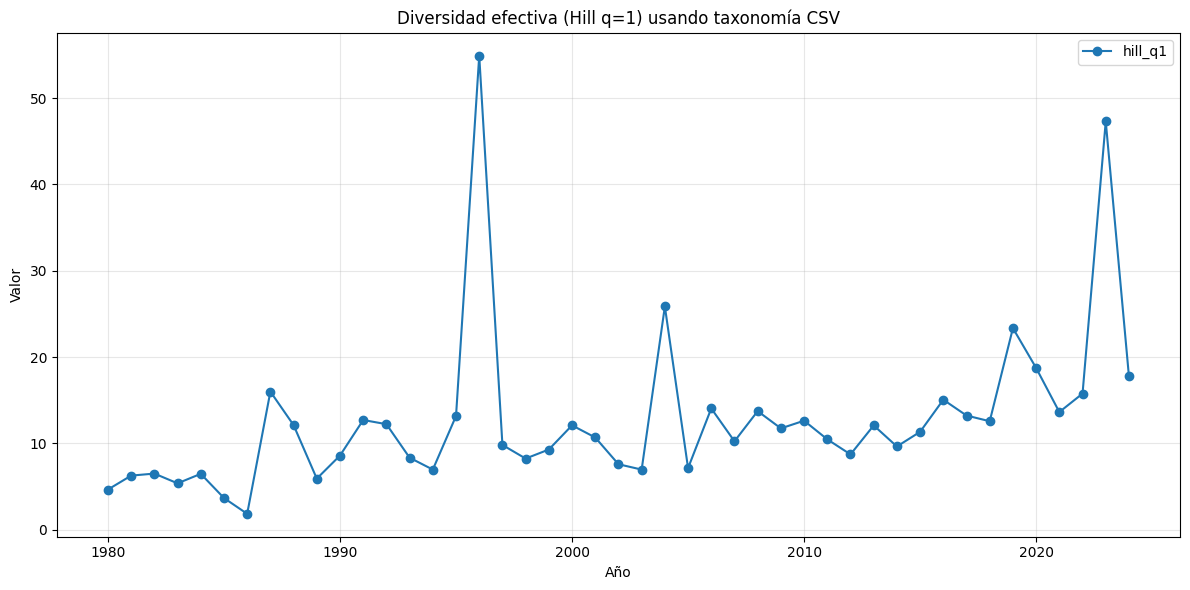

In [107]:
df = df_stage2.copy()
# diversidad efectiva (q=1)
viz.plot_timeseries_matplotlib(
    df,
    cols=["hill_q1"],
    title="Diversidad efectiva (Hill q=1) usando taxonomía CSV"
)


#Sobre clusters:
#“¿Cuántos grupos hay en el vecindario del ego este año?”
#“¿Está dominado por un solo grupo o está balanceado?”

#En la siguiente gráfica un pico alto significa que la masa (en este caso documentos) está más repartida entre varios clusters
#Un pico bajo significa que la masa está concentrada en pocos clusters.
#en 1996 la masa es mas diversa, la mayor concentracion está en unos 5 clusters
# en 1980 la masa está mas condensada en 2 clusters

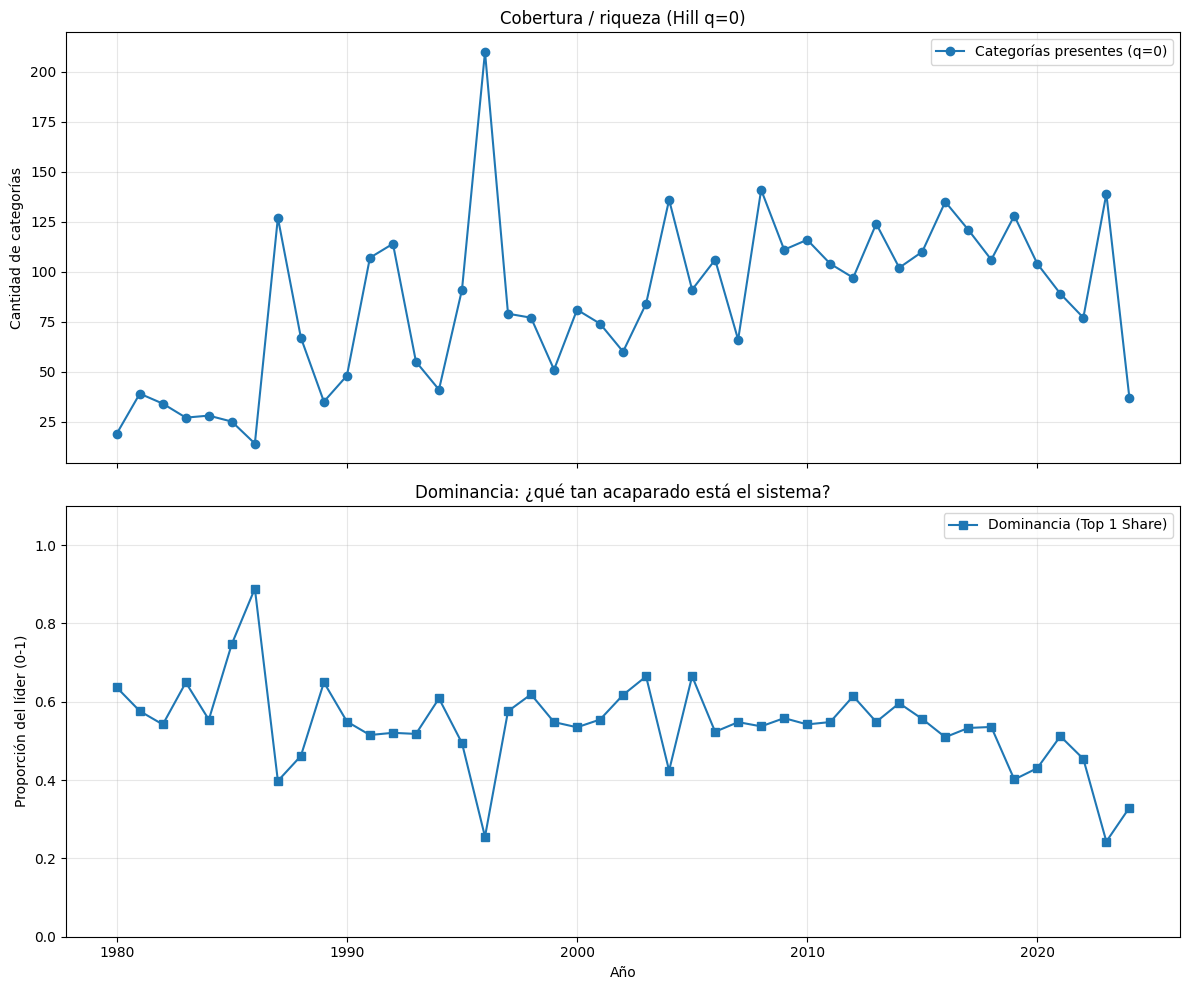

In [108]:
viz.plot_separated_metrics(df)
#EL top 1 share (masa) indica qué proporcion de la masa total está acaparada por el cluster más grande.
#Ej: si el valor es 0.90, entonces el 90% de la producción proviene de un único cluster

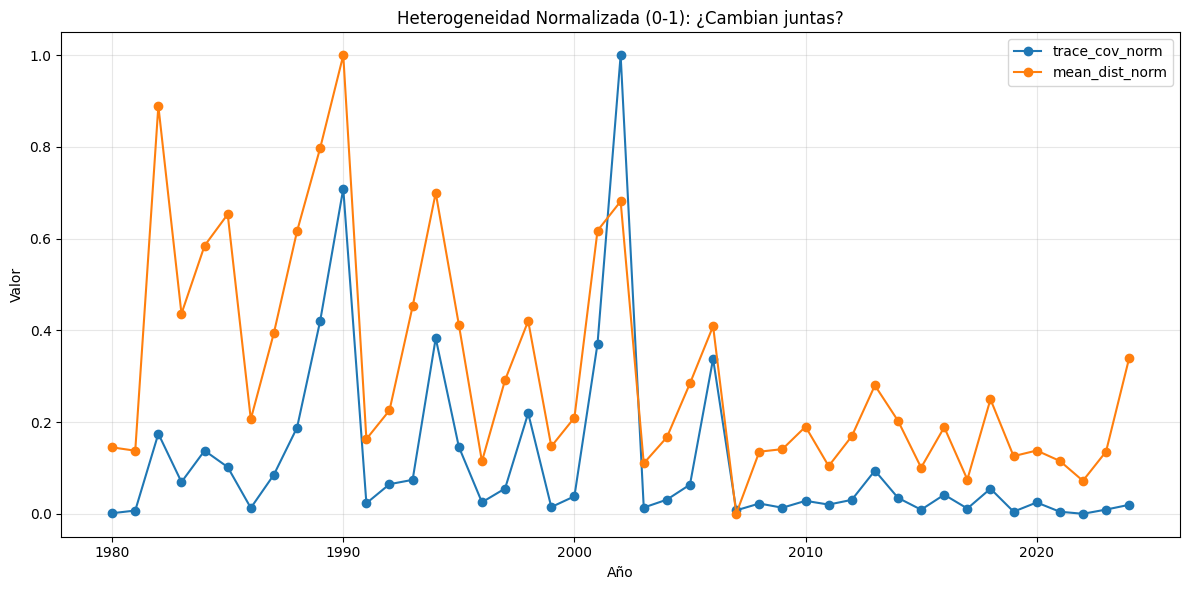

In [109]:
# Aplicamos la normalización (minmax) para que ambas vivan entre 0 y 1
df_norm = df.copy()
df_norm["trace_cov_norm"] = viz.minmax_01(df["trace_cov"])
df_norm["mean_dist_norm"] = viz.minmax_01(df["mean_dist_to_mu"])

viz.plot_timeseries_matplotlib(
    df_norm,
    cols=["trace_cov_norm", "mean_dist_norm"],
    title="Heterogeneidad Normalizada (0-1): ¿Cambian juntas?"
)

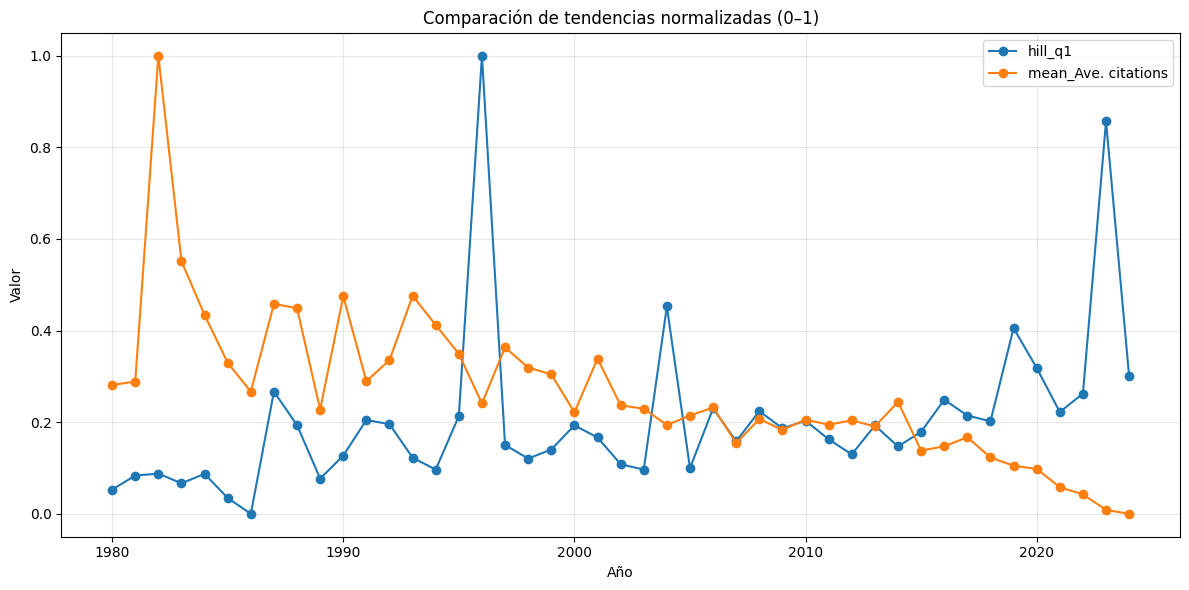

In [110]:
df_cmp = pd.DataFrame({"year": df["year"]})
to_compare = [
    "hill_q1",
   # "hill_strength_q1",
   # "mean_Ave. authorships",
    "mean_Ave. citations",
   # "top1_share_docs"
]

for c in to_compare:
    if c in df.columns:
        df_cmp[c] = viz.minmax_01(df[c])

viz.plot_timeseries_matplotlib(
    df_cmp,
    cols=[c for c in to_compare if c in df_cmp.columns],
    title="Comparación de tendencias normalizadas (0–1)"
)

#"Cuando el ego diversifica sus temas, tiende a colaborar con gente de mayor impacto" (hill vs documents)

In [111]:
# Correlacion de pearson
metrics_core = [
    "hill_q1", "hill_q2",
    "top1_share",
    "trace_cov", "mean_dist_to_mu",
    "mean_Ave. authorships", "mean_Ave. citations", "mean_Ave. references",
    "mean_Percent of documents", "mean_Percent of documents Int. Coll."
]

metrics_core = [c for c in metrics_core if c in df.columns]

df_metrics = df[metrics_core].copy()

corr_pearson = df_metrics.corr(method="pearson")
corr_spearman = df_metrics.corr(method="spearman")

print("\n--- Correlación Pearson (métricas core) ---")
print(corr_pearson.round(3))

print("\n--- Correlación Spearman (métricas core) ---")
print(corr_spearman.round(3))


--- Correlación Pearson (métricas core) ---
                                      hill_q1  hill_q2  top1_share  trace_cov  \
hill_q1                                 1.000    0.963      -0.826     -0.208   
hill_q2                                 0.963    1.000      -0.856     -0.185   
top1_share                             -0.826   -0.856       1.000      0.173   
trace_cov                              -0.208   -0.185       0.173      1.000   
mean_dist_to_mu                        -0.326   -0.229       0.215      0.752   
mean_Ave. authorships                   0.517    0.477      -0.558     -0.340   
mean_Ave. citations                    -0.358   -0.293       0.250      0.272   
mean_Ave. references                   -0.098    0.005      -0.046      0.635   
mean_Percent of documents              -0.450   -0.360       0.636      0.046   
mean_Percent of documents Int. Coll.    0.339    0.368      -0.346     -0.288   

                                      mean_dist_to_mu  mean_Ave

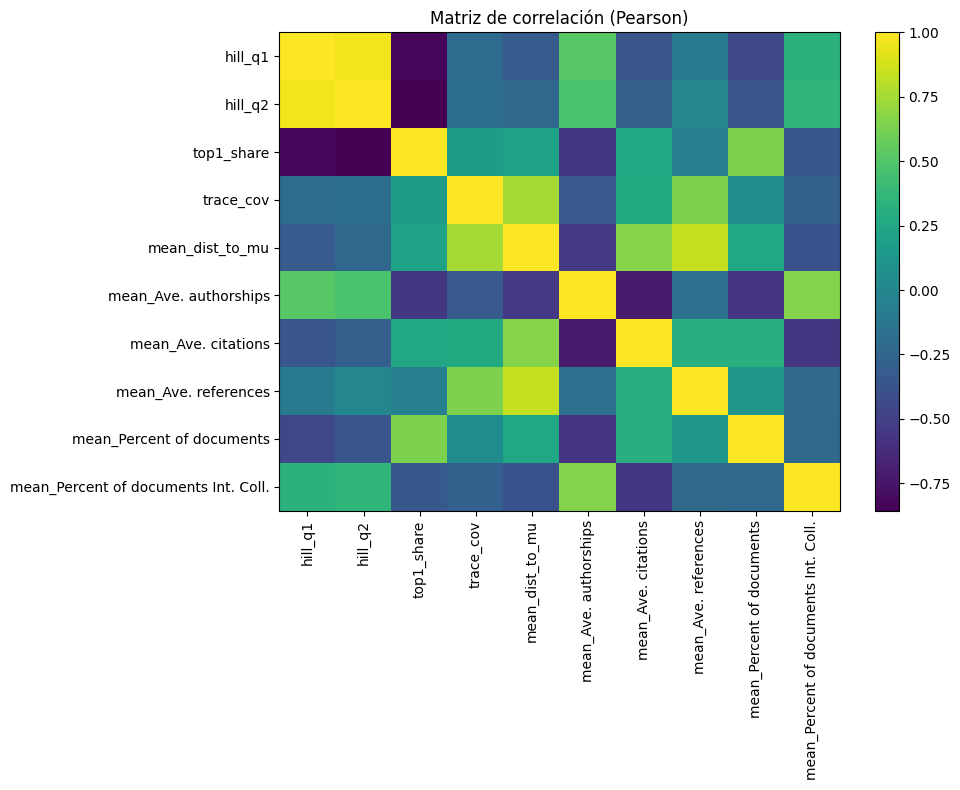

In [112]:
viz.plot_corr_matrix(corr_pearson, "Matriz de correlación (Pearson)")

In [113]:
feature_names = [k for (_, k) in global_cfg.FEATURES]
idx_docs = feature_names.index(cfg.DOCS_COL) if cfg.DOCS_COL in feature_names else None #Solo es para ubicar la posicion del feature "Documents,"


In [114]:
global_edges = analysis.compute_thresholds(snapshots, feature_names, cfg.CAT_SPECS, cfg.MODO_CUANTILES, cfg.TAMANO_VENTANA)

[OK] Ave. citations: edges globales = [ 2.77   9.    22.045]
[OK] Ave. references: edges globales = [31. 46. 73.]
[OK] Percent of documents Int. Coll.: edges globales = [ 0. 25.]
[OK] Ave. authorships: edges globales = [3.   4.02]


In [115]:
df_cats = analysis.generate_anual_proportions(snapshots, feature_names, cfg.CAT_SPECS, global_edges, idx_docs)

In [116]:
# df_cats = pd.DataFrame(rows_cat).sort_values("year").reset_index(drop=True)

out_path_cats = f"./Output/categorias_{cfg.LEVEL}_detallado.csv"
df_cats.to_csv(out_path_cats, index=False)
print(f"[OK] Guardado categorías: {out_path_cats}")


[OK] Guardado categorías: ./Output/categorias_meso_detallado.csv


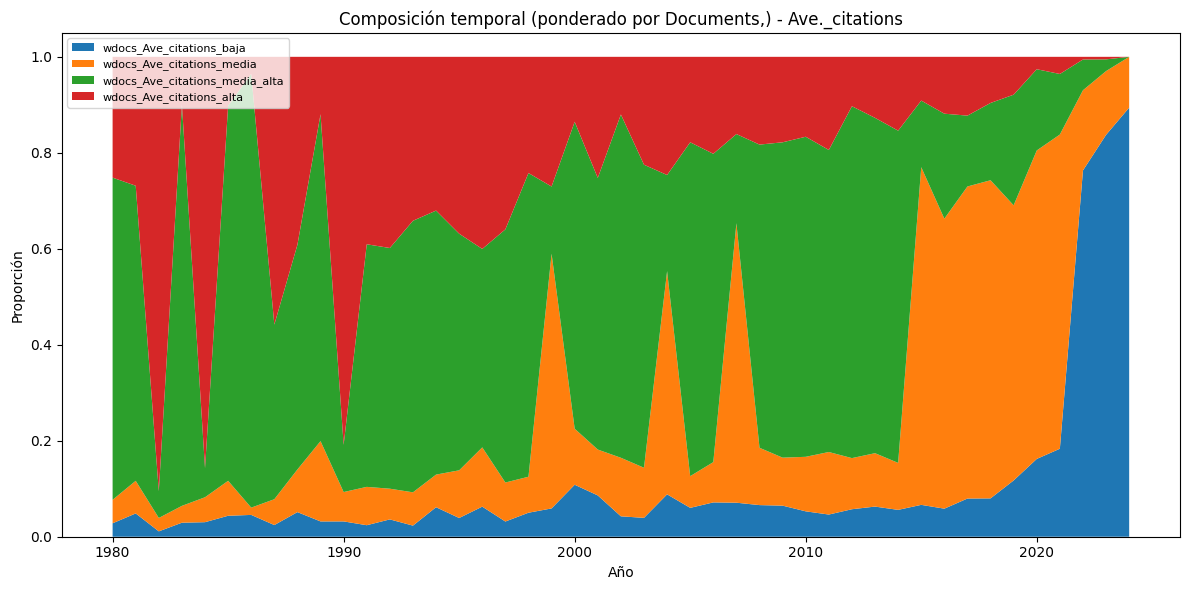

In [117]:
feat = "Ave._citations" # "Ave._references" "Percent of documents Int. Coll." "Ave._authorships"
viz.plot_feature_stack_shares(df_cats, feature_name=feat)

In [118]:
# Limpieza, cálculo de dominantes y separación
df_labels, df_values = analysis.procesar_etiquetas_y_valores(df_cats, cfg.CAT_SPECS)

In [119]:
out_dir = "./Output"
os.makedirs(out_dir, exist_ok=True)

out_path_labels = os.path.join(out_dir, f"categorias_{cfg.LEVEL}_simplificado_etiquetas.csv")
out_path_values = os.path.join(out_dir, f"categorias_{cfg.LEVEL}_simplificado_valores.csv")

df_labels.to_csv(out_path_labels, index=False, encoding="utf-8")
df_values.to_csv(out_path_values, index=False, encoding="utf-8")

print(f"[OK] Guardado etiquetas: {out_path_labels}")
print(f"[OK] Guardado valores (max share): {out_path_values}")

print("\n--- Preview etiquetas ---")
print(df_labels.head())

print("\n--- Preview valores ---")
print(df_values.head())



[OK] Guardado etiquetas: ./Output/categorias_meso_simplificado_etiquetas.csv
[OK] Guardado valores (max share): ./Output/categorias_meso_simplificado_valores.csv

--- Preview etiquetas ---
   year unw_Ave_citations wdocs_Ave_citations unw_Ave_references  \
0  1980              alta          media_alta               alta   
1  1981              alta          media_alta              media   
2  1982              alta                alta               alta   
3  1983        media_alta          media_alta               baja   
4  1984              alta                alta               alta   

  wdocs_Ave_references unw_Percent_of_documents_Int_Coll  \
0                media                              baja   
1                media                              baja   
2                media                              baja   
3                media                              baja   
4                media                              baja   

  wdocs_Percent_of_documents_Int_Coll unw

In [120]:
'''
Cuantiles globales hacen que las citas se vean afectadas, por ejemplo un articulo de 2024 sera catalogado como bajo
porque no ha "madurado", en cambio un articulo del 2000 ya pasaron decadas acumulando citas.
"Normalizacion temporal por ventana"
'''

'\nCuantiles globales hacen que las citas se vean afectadas, por ejemplo un articulo de 2024 sera catalogado como bajo\nporque no ha "madurado", en cambio un articulo del 2000 ya pasaron decadas acumulando citas.\n"Normalizacion temporal por ventana"\n'

In [121]:
# Evolución de Categorías

df_combinado = cat_plots.cargar_datos_categorias(cfg.LEVEL)
cat_plots.plot_evolucion_categorias(df_combinado, cfg.CATEGORICAL_FEATURES, seleccion="citas", usar_lowess=False)

#citas, referencias, porcentaje_docs_int, autores


In [122]:
''' 
Propiedades a cumplirse por los residuos:
Homocedasticidad
normalidad
independencia

y los datos deben ser lineales


Un residuo es la diferencia exacta entre la realidad y lo que la ecuación calculó.

'''

' \nPropiedades a cumplirse por los residuos:\nHomocedasticidad\nnormalidad\nindependencia\n\ny los datos deben ser lineales\n\n\nUn residuo es la diferencia exacta entre la realidad y lo que la ecuación calculó.\n\n'

In [123]:
# Carga los datos incluyendo las distribuciones completas
df_completo = cat_plots.cargar_datos_completos(cfg.LEVEL)

# Llama a la nueva gráfica integrada indicando la feature (e.g. "citas")
cat_plots.plot_evolucion_completa(df_completo, cfg.CATEGORICAL_FEATURES, seleccion="citas")


In [124]:
# Mandar llamar a la nueva función
df_completo = category_plots.cargar_datos_completos(cfg.LEVEL)
category_plots.plot_evolucion_traslapada(df_completo, cfg.CATEGORICAL_FEATURES, seleccion="citas")


In [125]:
# Cargar los datos y graficar
df_completo = category_plots.cargar_datos_completos(cfg.LEVEL)
category_plots.plot_peak_dominance(df_completo, cfg.CATEGORICAL_FEATURES, seleccion="citas")
